## MACHINE LEARNING DAY-8 : Random Forest Regression

### What is **Random Forest Regression**?

**Random Forest Regression** is an ensemble machine learning algorithm that uses **multiple decision trees** to make **better, more stable predictions** for **continuous numerical values**.

It builds on the idea that **a "forest" of trees is better than one** — by combining the predictions of many individual trees, it reduces overfitting and improves accuracy.

---

#### Core Idea

* A **Decision Tree** can easily overfit the training data.
* A **Random Forest** grows **many decision trees**, each trained on a **random subset** of the data and features.
* The final prediction is the **average of all trees’ predictions** (for regression).

---

#### Regression vs Classification

| Task           | Output                          |
| -------------- | ------------------------------- |
| Classification | Majority vote of trees          |
| **Regression** | **Average of tree predictions** |

---

#### How It Works

1. Randomly select **samples with replacement** (bootstrap sampling) → each tree gets a different subset of data.
2. For each split in a tree, use a **random subset of features**.
3. Build each tree **independently** to the max depth or stopping criteria.
4. **Aggregate predictions**:

   * In regression, take the **mean** of all tree outputs.

---

#### Advantages

* Handles **nonlinear relationships** well
* **Reduces overfitting** compared to a single tree
* **Works out-of-the-box** with minimal tuning
* Handles large datasets and many features

---

#### Disadvantages

* Less interpretable than a single tree
* Can be slower to predict (due to many trees)
* Larger model size

---

#### Visual Intuition

Imagine 100 noisy decision trees giving predictions like:

```
Tree 1: 150
Tree 2: 160
Tree 3: 140
...
Tree 100: 155
```

🟰 Final Prediction = **Average** = 151.2

### Import the Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the dataset

In [2]:
df = pd.read_csv('../datasets/Position_Salaries.csv')
print(df)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [3]:
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
print(X)
print('\n')
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


### Training the Random Forest regressor on whole dataset

In [4]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X,y)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predicting a new result

In [5]:
y_pred_new = regressor.predict([[6.5]])
print(y_pred_new)

[167000.]


### Visualising the decision tree results

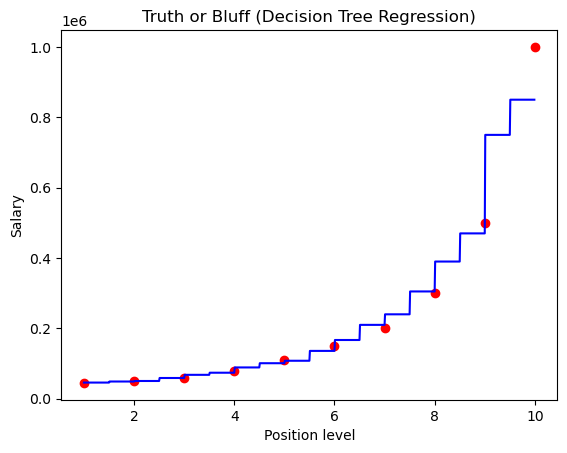

In [6]:
X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)

plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

### Evaluating the performance metrics

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = regressor.predict(X)

print('R2 Score : ',r2_score(y, y_pred))
print('MAE Score : ',mean_absolute_error(y, y_pred))
print('MSE Score : ',mean_squared_error(y, y_pred))
print("RMSE : ", mean_squared_error(y, y_pred))

R2 Score :  0.9704434230386582
MAE Score :  22700.0
MSE Score :  2384100000.0
RMSE :  2384100000.0
